In [15]:
from sklearn.datasets import load_diabetes, load_breast_cancer
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes, load_breast_cancer

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier

from sklearn.neighbors import KNeighborsRegressor
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("All libraries imported successfully!")

All libraries imported successfully!


In [16]:
diabetes = load_diabetes()

X_reg = pd.DataFrame(
    diabetes.data,
    columns=diabetes.feature_names
)

y_reg = pd.Series(
    diabetes.target,
    name="Target"
)

cancer = load_breast_cancer()

X_clf = pd.DataFrame(
    cancer.data,
    columns=cancer.feature_names
)

y_clf = pd.Series(
    cancer.target,
    name="Target"
)

print("REGRESSION DATASET")
print("Shape:", X_reg.shape)
print(X_reg.head())

print("\nCLASSIFICATION DATASET")
print("Shape:", X_clf.shape)
print(X_clf.head())

print("\nClassification target classes:")
print(cancer.target_names)

REGRESSION DATASET
Shape: (442, 10)
        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  
0 -0.002592  0.019907 -0.017646  
1 -0.039493 -0.068332 -0.092204  
2 -0.002592  0.002861 -0.025930  
3  0.034309  0.022688 -0.009362  
4 -0.002592 -0.031988 -0.046641  

CLASSIFICATION DATASET
Shape: (569, 30)
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          13

In [17]:

# Split regression data
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

# Split classification data
X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
    X_clf,
    y_clf,
    test_size=0.2,
    random_state=42,
    stratify=y_clf
)

# Scale features using training data only
reg_scaler = StandardScaler()
X_reg_train_scaled = reg_scaler.fit_transform(X_reg_train)
X_reg_test_scaled = reg_scaler.transform(X_reg_test)

clf_scaler = StandardScaler()
X_clf_train_scaled = clf_scaler.fit_transform(X_clf_train)
X_clf_test_scaled = clf_scaler.transform(X_clf_test)

print("Data preprocessing completed!")
print("Regression training samples:", len(X_reg_train))
print("Regression testing samples:", len(X_reg_test))
print("Classification training samples:", len(X_clf_train))
print("Classification testing samples:", len(X_clf_test))

Data preprocessing completed!
Regression training samples: 353
Regression testing samples: 89
Classification training samples: 455
Classification testing samples: 114


In [7]:

# Create regression models
regression_models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ),
    "KNN": KNeighborsRegressor(n_neighbors=5)
}

# Train and evaluate models
regression_results = []
regression_predictions = {}

for name, model in regression_models.items():

    # KNN requires scaled data
    if name == "KNN":
        model.fit(X_reg_train_scaled, y_reg_train)
        predictions = model.predict(X_reg_test_scaled)
    else:
        model.fit(X_reg_train, y_reg_train)
        predictions = model.predict(X_reg_test)

    regression_predictions[name] = predictions

    mae = mean_absolute_error(y_reg_test, predictions)
    mse = mean_squared_error(y_reg_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_reg_test, predictions)

    regression_results.append({
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2 Score": r2
    })

# Display regression results
regression_df = pd.DataFrame(regression_results)

print("REGRESSION MODEL PERFORMANCE")
display(regression_df.round(4))

REGRESSION MODEL PERFORMANCE


,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,42.7941,2900.1936,53.8534,0.4526
1,Decision Tree,54.5281,4976.7978,70.5464,0.0607
2,Random Forest,44.0530,2952.0106,54.3324,0.4428
3,KNN,42.7775,3047.4499,55.2037,0.4248


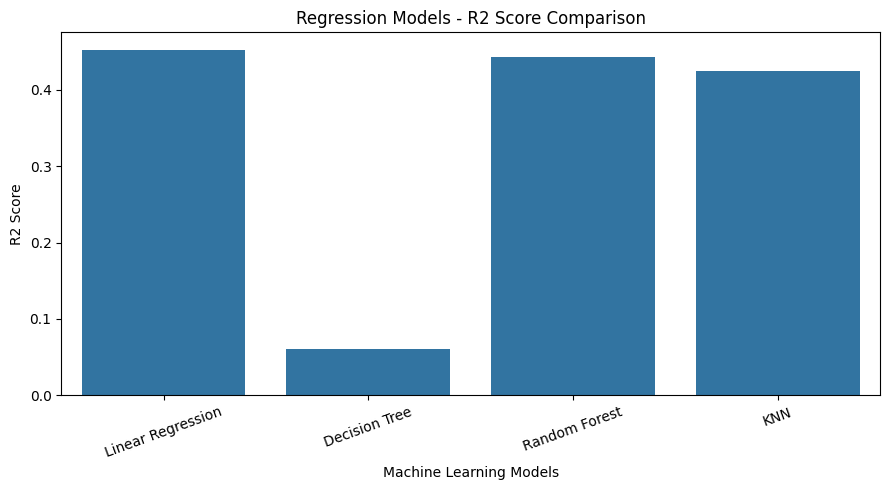

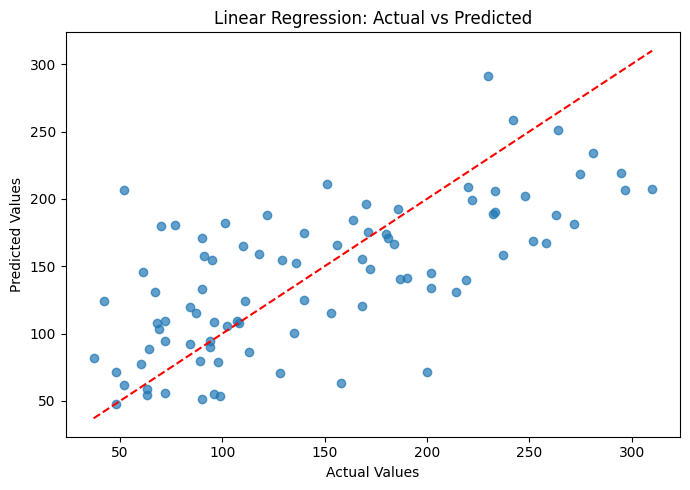

In [8]:

# Compare regression models using R2 score
plt.figure(figsize=(9, 5))

sns.barplot(
    data=regression_df,
    x="Model",
    y="R2 Score"
)

plt.title("Regression Models - R2 Score Comparison")
plt.xlabel("Machine Learning Models")
plt.ylabel("R2 Score")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# Compare actual and predicted values for Linear Regression
plt.figure(figsize=(7, 5))

plt.scatter(
    y_reg_test,
    regression_predictions["Linear Regression"],
    alpha=0.7
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Linear Regression: Actual vs Predicted")

min_val = min(y_reg_test.min(),
              regression_predictions["Linear Regression"].min())
max_val = max(y_reg_test.max(),
              regression_predictions["Linear Regression"].max())

plt.plot([min_val, max_val], [min_val, max_val], "r--")
plt.tight_layout()
plt.show()

In [9]:

# Create classification models
classification_models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

# Store results and predictions
classification_results = []
classification_predictions = {}

# Train and evaluate each model
for name, model in classification_models.items():

    # Use scaled data for Logistic Regression and KNN
    if name in ["Logistic Regression", "KNN"]:
        model.fit(X_clf_train_scaled, y_clf_train)
        predictions = model.predict(X_clf_test_scaled)
    else:
        model.fit(X_clf_train, y_clf_train)
        predictions = model.predict(X_clf_test)

    classification_predictions[name] = predictions

    accuracy = accuracy_score(y_clf_test, predictions)
    precision = precision_score(
        y_clf_test, predictions, zero_division=0
    )
    recall = recall_score(
        y_clf_test, predictions, zero_division=0
    )
    f1 = f1_score(
        y_clf_test, predictions, zero_division=0
    )

    classification_results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

# Display results
classification_df = pd.DataFrame(classification_results)

print("CLASSIFICATION MODEL PERFORMANCE")
display(classification_df.round(4))

CLASSIFICATION MODEL PERFORMANCE


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.9825,0.9861,0.9861,0.9861
1,Decision Tree,0.9123,0.9559,0.9028,0.9286
2,Random Forest,0.9561,0.9589,0.9722,0.9655
3,KNN,0.9561,0.9589,0.9722,0.9655


In [10]:

# Detailed classification report for each model
for name, predictions in classification_predictions.items():

    print("\n", "=" * 50)
    print(name)
    print("=" * 50)

    print(classification_report(
        y_clf_test,
        predictions,
        target_names=cancer.target_names,
        zero_division=0
    ))


Logistic Regression
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


Decision Tree
              precision    recall  f1-score   support

   malignant       0.85      0.93      0.89        42
      benign       0.96      0.90      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114


Random Forest
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96

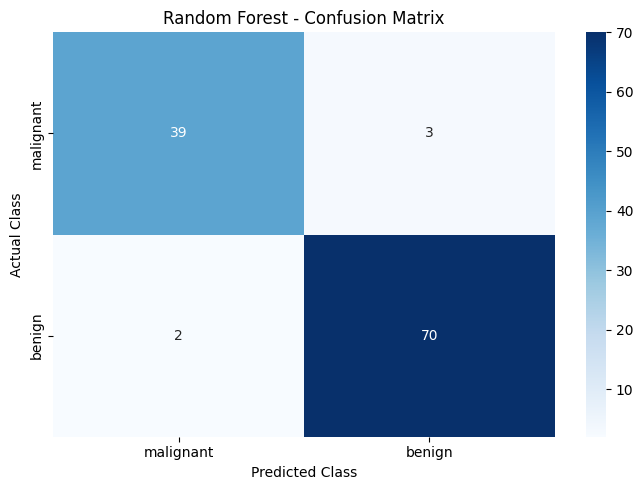

In [11]:

# Confusion matrix for Random Forest
rf_predictions = classification_predictions["Random Forest"]

cm = confusion_matrix(y_clf_test, rf_predictions)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=cancer.target_names,
    yticklabels=cancer.target_names
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

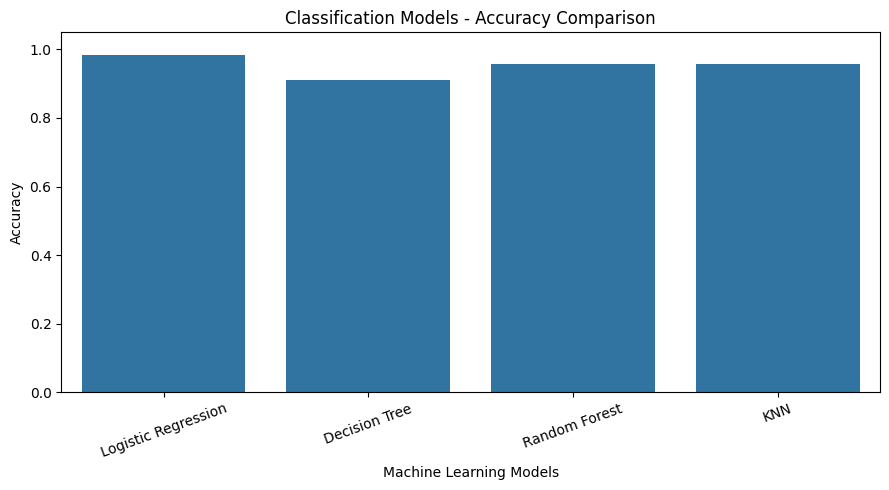

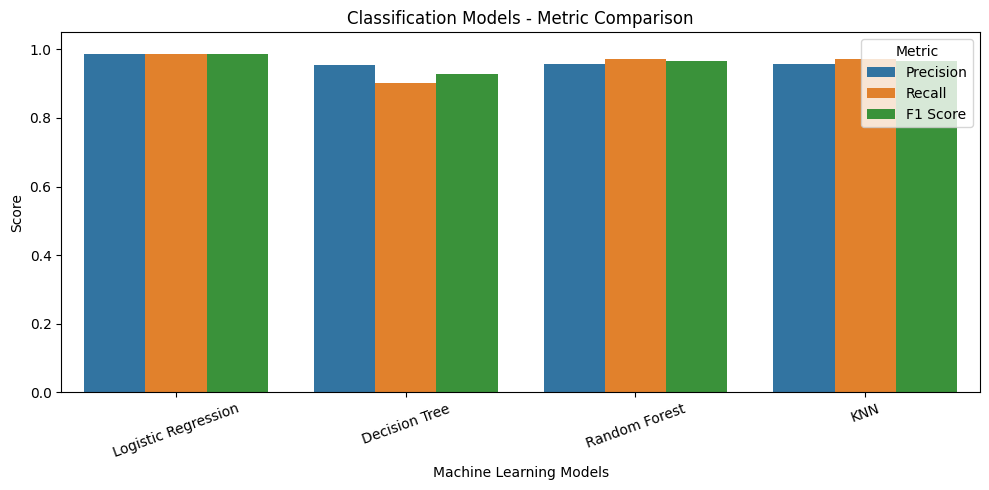

In [12]:

# Compare classification accuracy
plt.figure(figsize=(9, 5))

sns.barplot(
    data=classification_df,
    x="Model",
    y="Accuracy"
)

plt.title("Classification Models - Accuracy Comparison")
plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# Compare precision, recall and F1 score
metrics_df = classification_df.melt(
    id_vars="Model",
    value_vars=["Precision", "Recall", "F1 Score"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=metrics_df,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.title("Classification Models - Metric Comparison")
plt.xlabel("Machine Learning Models")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [13]:

# Select one test sample
sample = X_clf_test.iloc[[0]]

# Predict using trained Random Forest model
prediction = classification_models["Random Forest"].predict(sample)

predicted_class = cancer.target_names[prediction[0]]

actual_class = cancer.target_names[y_clf_test.iloc[0]]

print("Predicted class:", predicted_class)
print("Actual class:", actual_class)

Predicted class: malignant
Actual class: malignant


In [14]:

# Display final regression comparison
print("FINAL REGRESSION COMPARISON")
display(
    regression_df.sort_values(
        by="R2 Score",
        ascending=False
    ).reset_index(drop=True).round(4)
)

# Display final classification comparison
print("\nFINAL CLASSIFICATION COMPARISON")
display(
    classification_df.sort_values(
        by="Accuracy",
        ascending=False
    ).reset_index(drop=True).round(4)
)

print("\nModel training and evaluation completed successfully!")

FINAL REGRESSION COMPARISON


,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,42.7941,2900.1936,53.8534,0.4526
1,Random Forest,44.0530,2952.0106,54.3324,0.4428
2,KNN,42.7775,3047.4499,55.2037,0.4248
3,Decision Tree,54.5281,4976.7978,70.5464,0.0607



FINAL CLASSIFICATION COMPARISON


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.9825,0.9861,0.9861,0.9861
1,Random Forest,0.9561,0.9589,0.9722,0.9655
2,KNN,0.9561,0.9589,0.9722,0.9655
3,Decision Tree,0.9123,0.9559,0.9028,0.9286



Model training and evaluation completed successfully!
